# Spatial transcriptomics analysis

- Reference: https://www.sc-best-practices.org/cellular_structure/annotation.html

In [3]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import math
import seaborn as sns
from scipy.stats import median_abs_deviation

In [4]:
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/2174054843.py:8: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [5]:
#sc.logging.print_versions()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3
out_folder = "results"

In [6]:
# parameters
sample_ids = ["LNEN071-IARC-A", "LNEN084-IARC-B", "LNEN107-IARC-C", "LNEN206-IARC-D"]

In [7]:
# some hub genes from Nicolas's paper
test_genes = {
  "Carcinoid_A1": ["DLL3", "ASCL1"],
  "Carcinoid_A2": ["ROBO1", "SLIT1"],
  "Supraca": ["PD-L1"],
  "LCNEC": ["ANGPTL3", "OTP", "NKX2-1", "ERBB4"]
}

## Import data

In [8]:
def find_outliers(dat):
    q3, q1 = np.percentile(dat, [75 ,25])
    IQR = q3-q1
    lower_bound, upper_bound = np.percentile(dat, [1 ,99])
    return q3,q1,lower_bound,upper_bound

In [9]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

reading data/nicolas_spatial_data/LungNENomics-spatialRNAseq/LNEN071-IARC-A/filtered_feature_bc_matrix.h5
 (0:00:00)


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Total number of cells: 4012
Number of cells after filtering of low quality cells: 3644
normalizing counts per cell


/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:49: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts"], kde=False, ax=axes[6*i])
/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:101: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
reading data/nicolas_spatial_data/LungNENomics-spatialRNAseq/LNEN084-IARC-B/filtered_feature_bc_matrix.h5
 (0:00:00)


...

/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:49: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts"], kde=False, ax=axes[6*i])
/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:101: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
reading data/nicolas_spatial_data/LungNENomics-spatialRNAseq/LNEN206-IARC-D/filtered_feature_bc_matrix.h5
 (0:00:00)


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:49: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts"], kde=False, ax=axes[6*i])


Total number of cells: 3102
Number of cells after filtering of low quality cells: 3080
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:101: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts"], kde=False, ax=axes[6*i+1])
/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_41286/1739782435.py:136: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


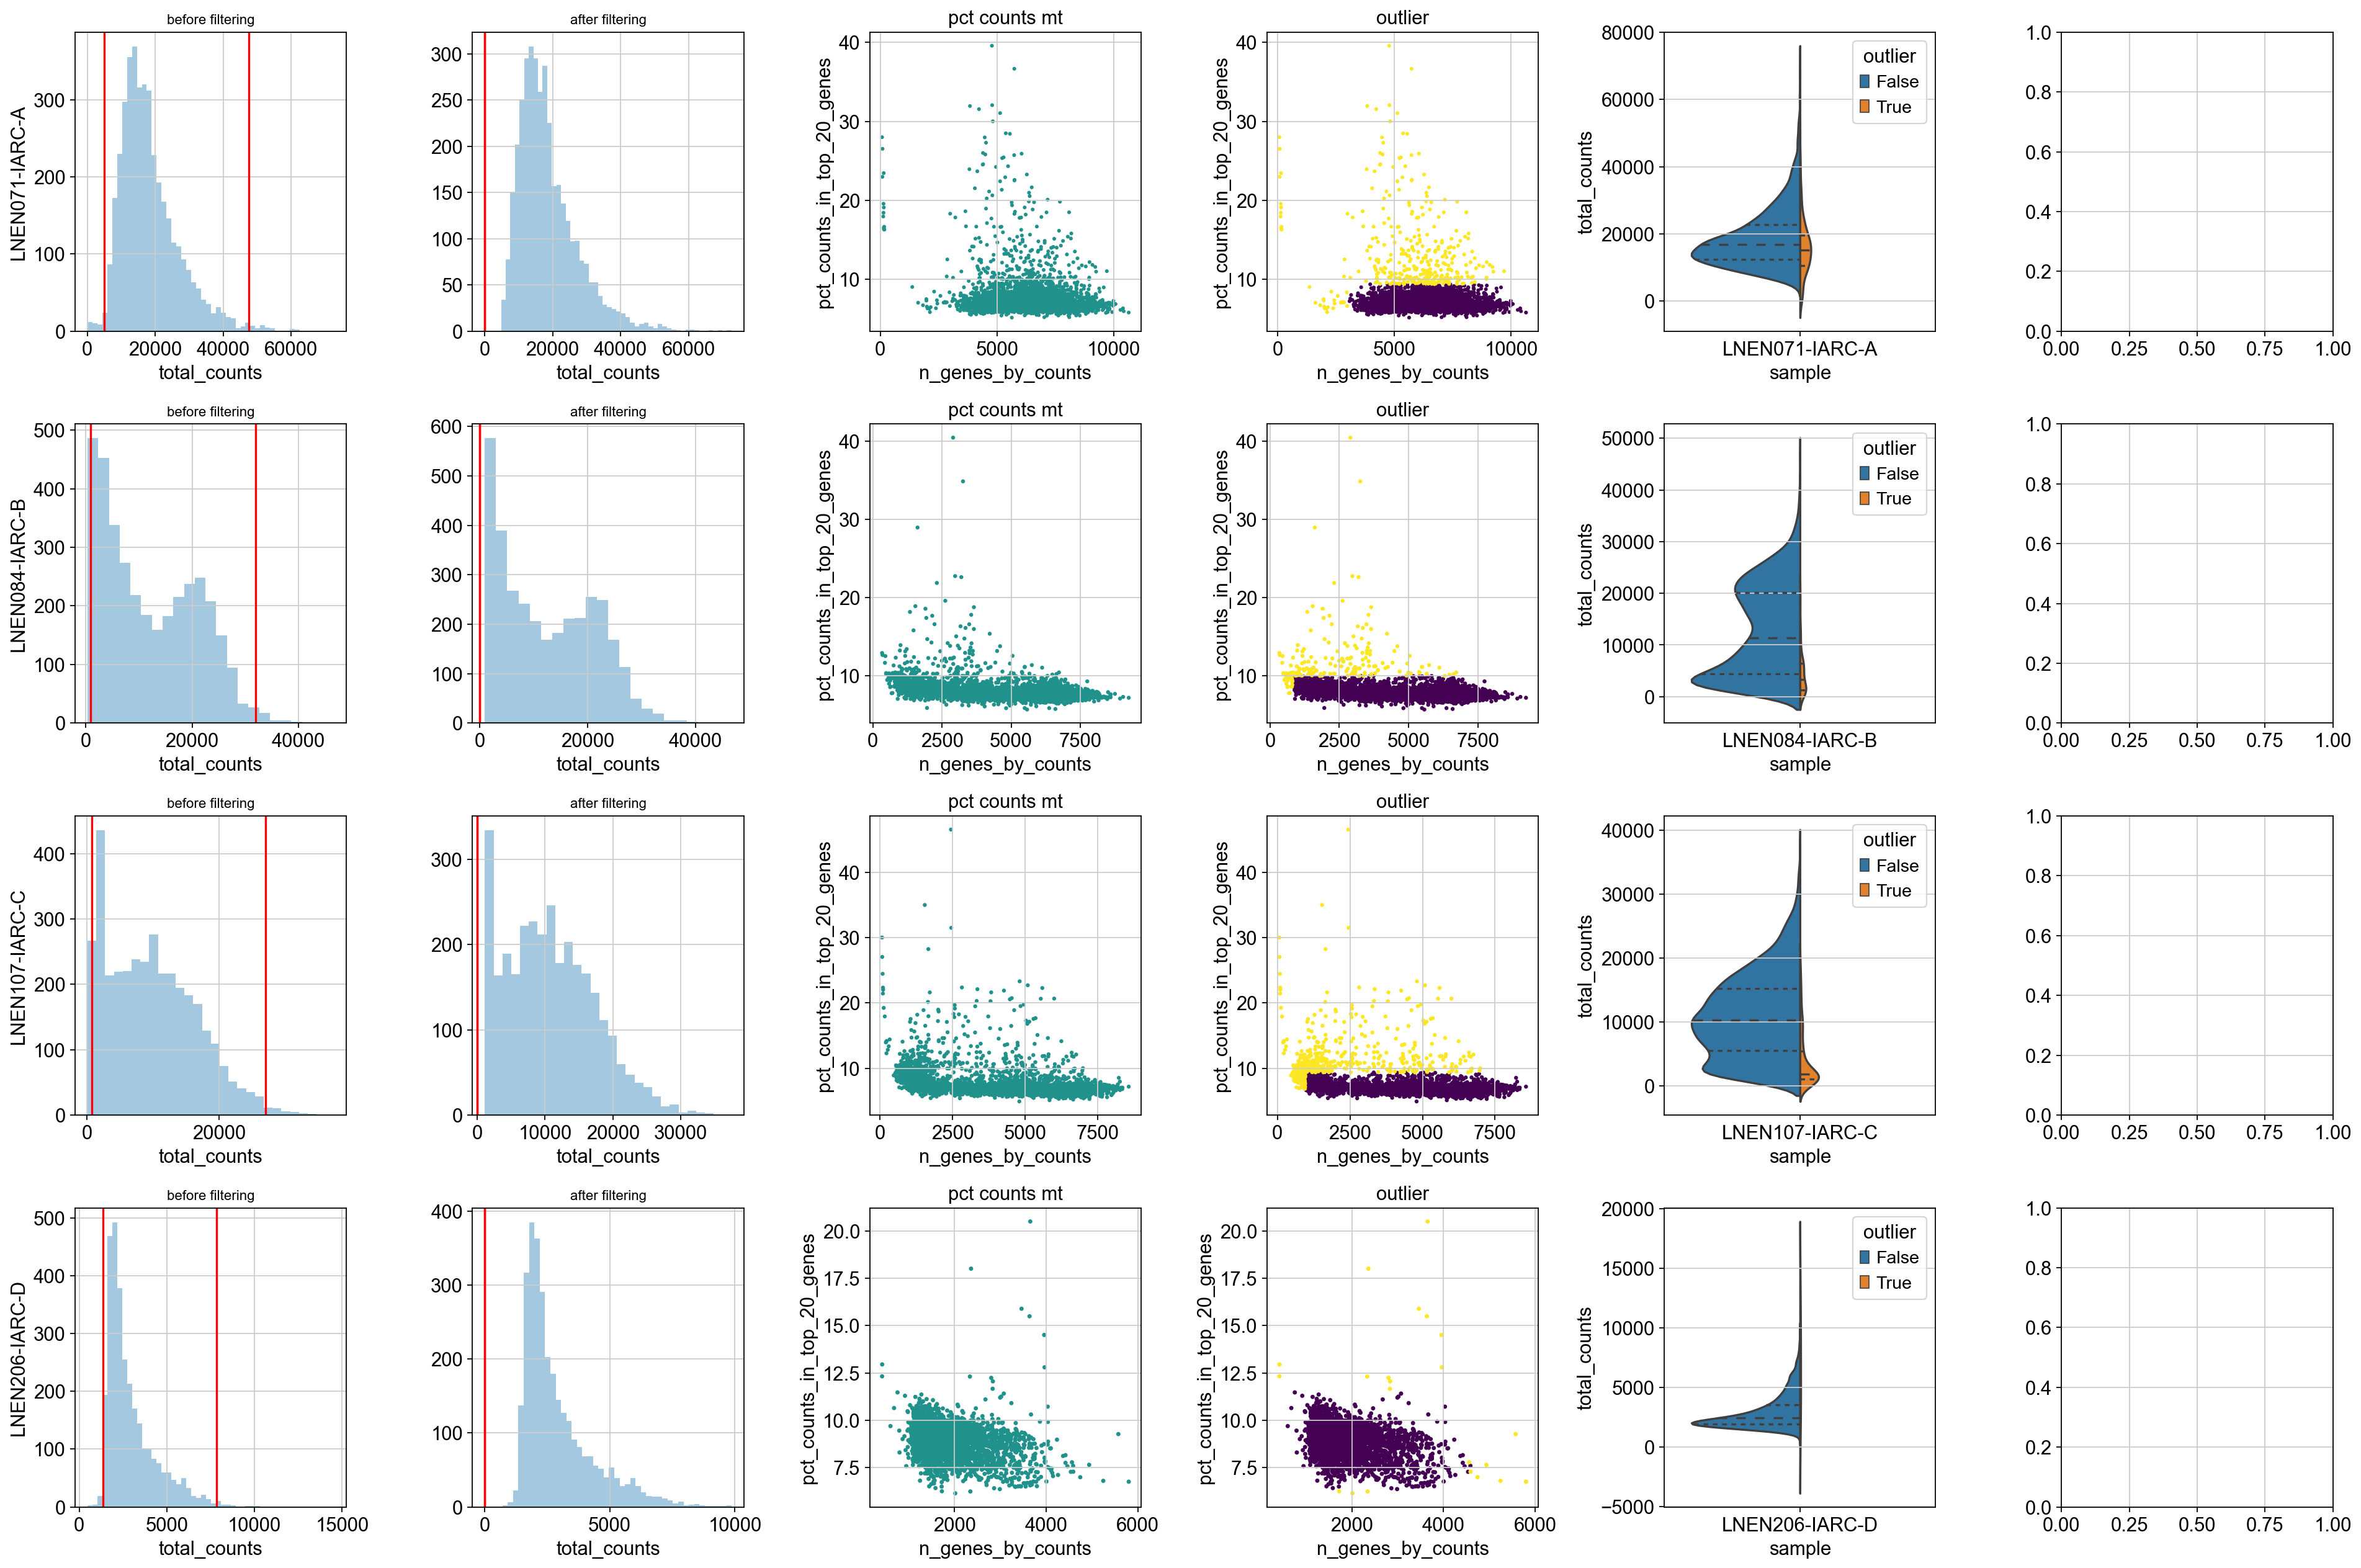

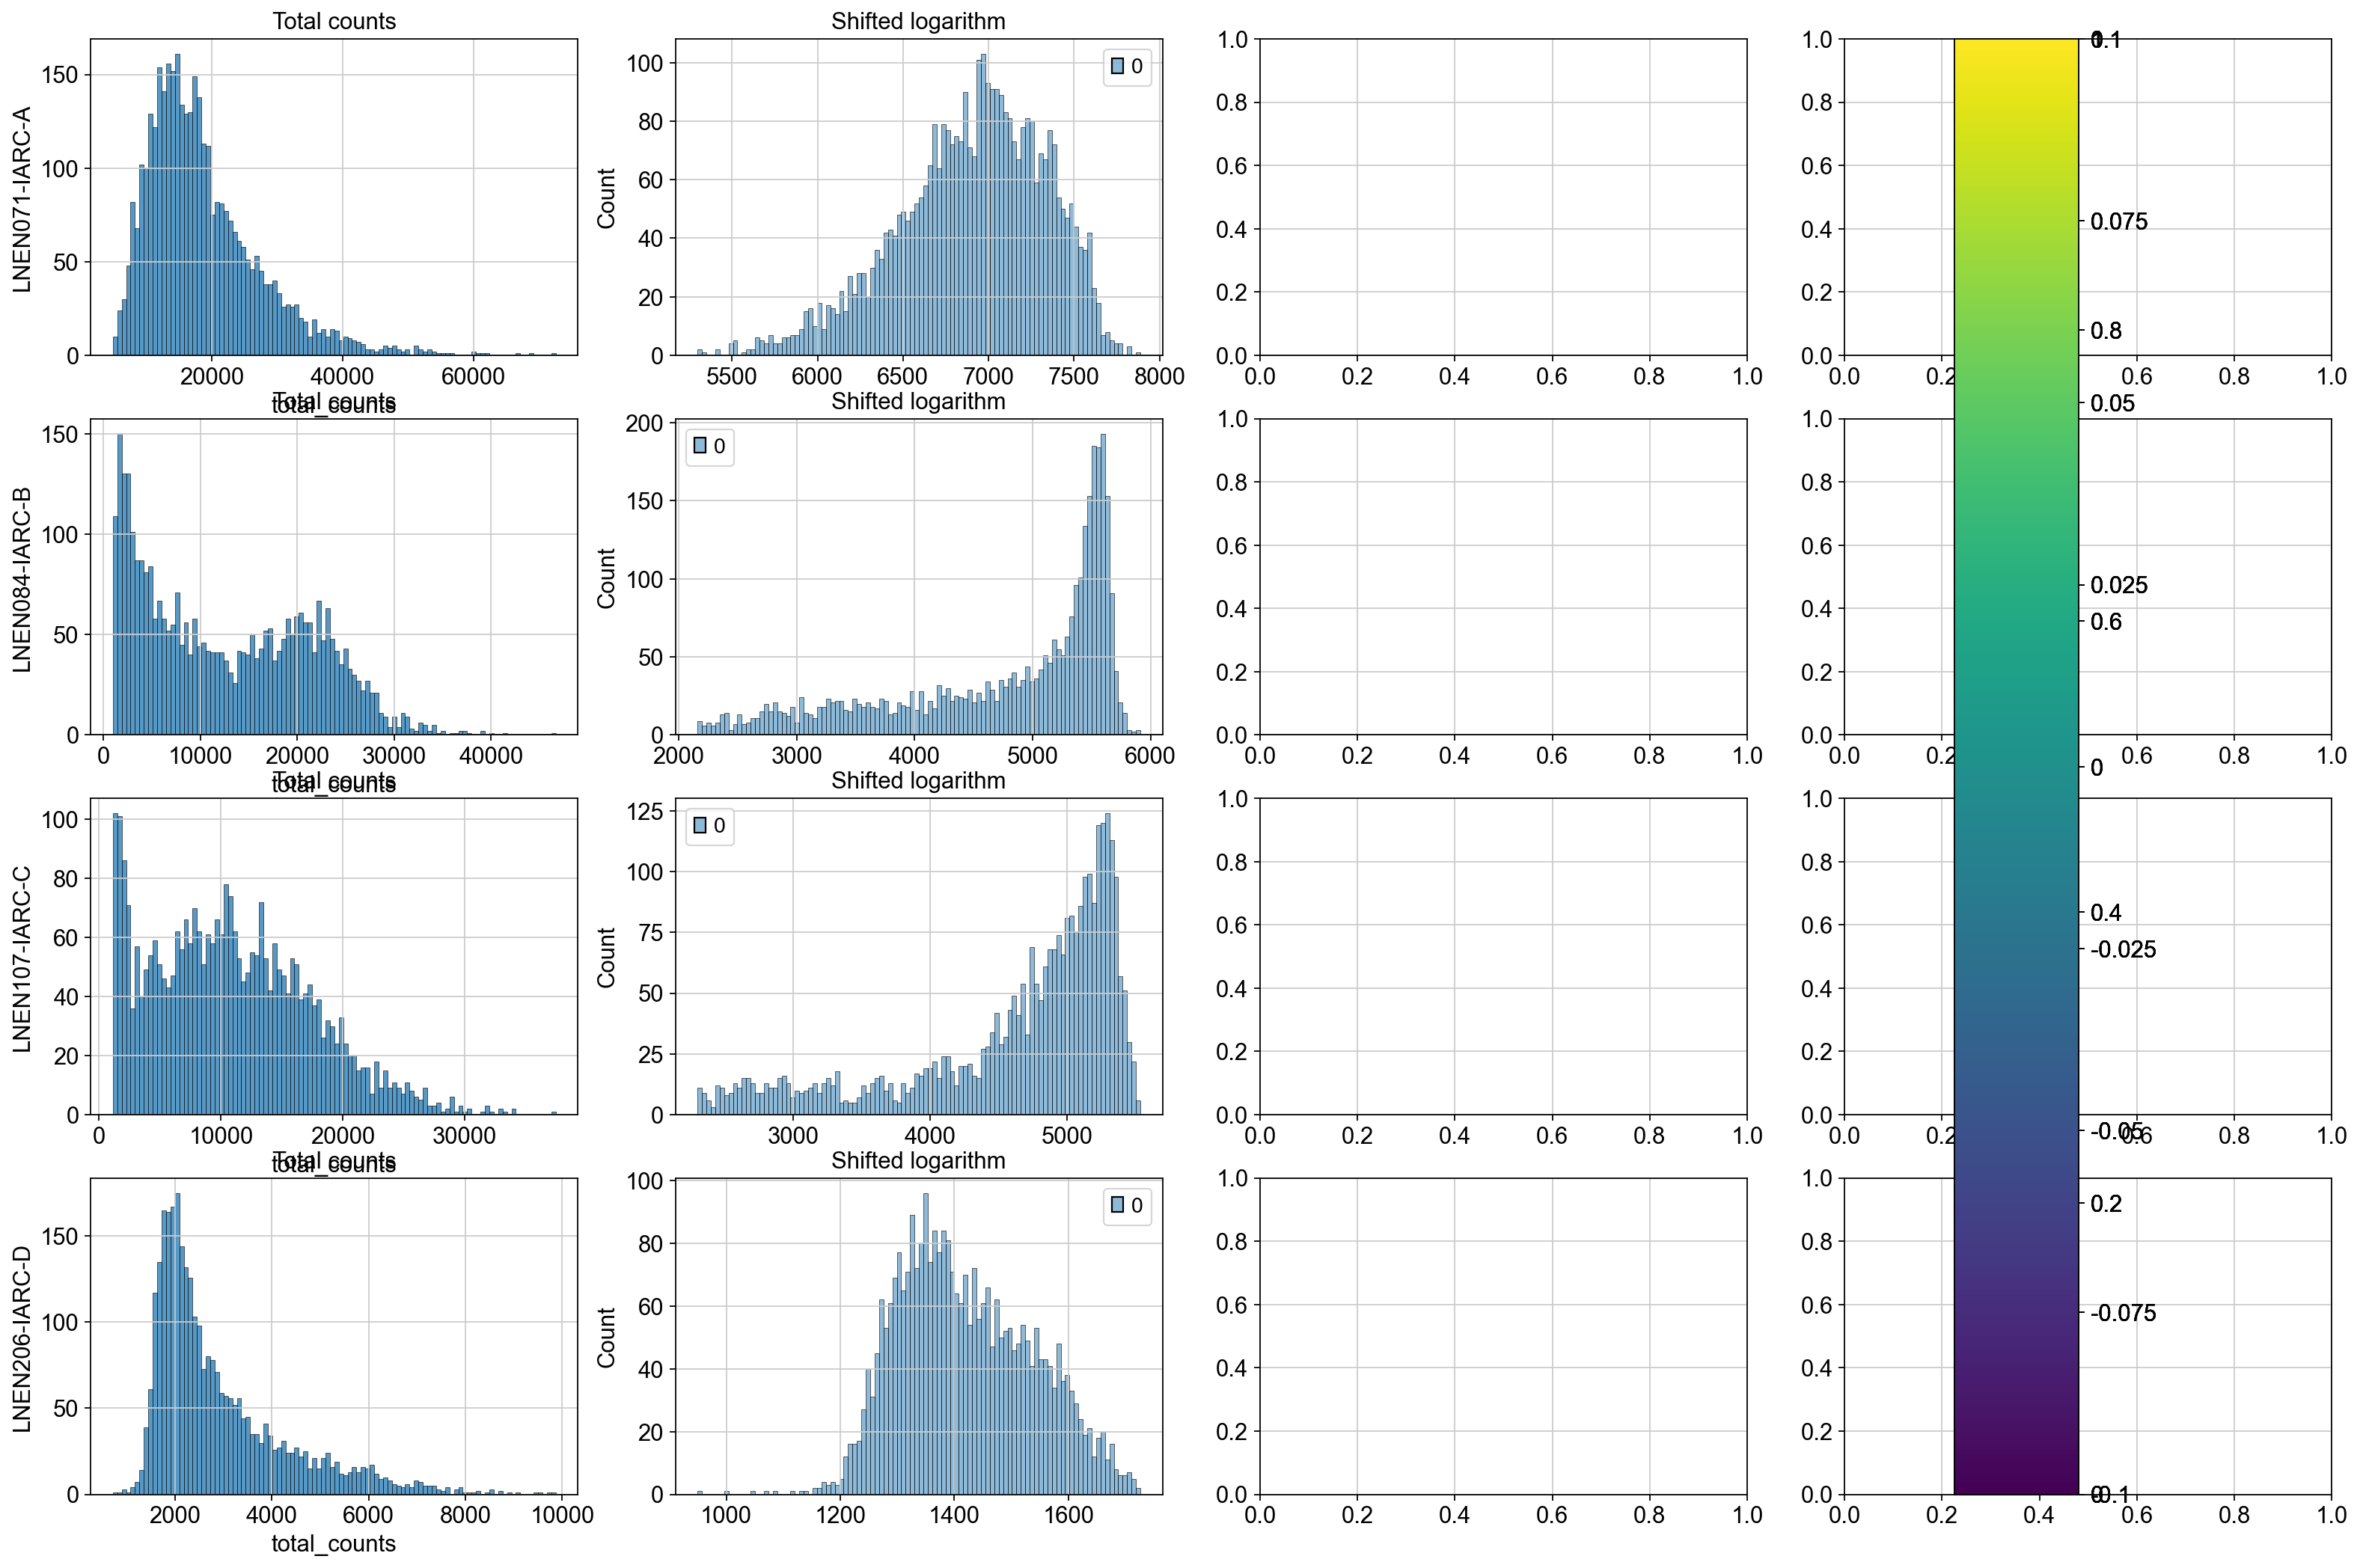

In [18]:
ddir = os.path.join("data", "nicolas_spatial_data")
adatas = []

fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

fig2, axes2 = plt.subplots(4, 4, figsize=(24, 16))
axes2 = axes2.flatten()

for i in range(len(sample_ids)):
    sample_id = sample_ids[i]
    sample_ddir = os.path.join(ddir, "LungNENomics-spatialRNAseq", sample_id)
    adata = sc.read_visium(sample_ddir)
    adata.var_names_make_unique()
    adata.obs['sample'] = sample_id
    
    # mitochondrial genes
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    # ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith("RP[SL]")
    # calculate QC metrics
    sc.pp.calculate_qc_metrics(
        adata, 
        qc_vars=["mt", "ribo"], 
        percent_top = (20, 50, 100, 200, 500),
        inplace=True
    )
    
    # identify outlier via MAD
    adata.obs["outlier"] = (
        is_outlier(adata, "log1p_total_counts", 5)
        | is_outlier(adata, "log1p_n_genes_by_counts", 5)
        | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    )
    adata.obs.outlier.value_counts()
    
    # identify outlier via MT gene pct
    # !!! percentage of MT gene is all 0
    adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
        adata.obs["pct_counts_mt"] > 20
    )
    adata.obs.mt_outlier.value_counts()
    
    # visualize
    q3,q1,tc_lower_bound,tc_upper_bound = find_outliers(adata.obs["total_counts"])
    q3_,q1_,tc_lower_bound_,tc_upper_bound_ = find_outliers(adata.obs["log1p_total_counts"])
    
    
    sns.distplot(adata.obs["total_counts"], kde=False, ax=axes[6*i])
    axes[6*i].axvline(tc_lower_bound, color='red')
    axes[6*i].axvline(tc_upper_bound, color='red')
    axes[6*i].set_title(f'before filtering', fontsize=10)
    axes[6*i].set_ylabel(sample_id)
    
    """
    sns.distplot(adata.obs["log1p_total_counts"], kde=False, ax=axes[6*i])
    axes[6*i].axvline(tc_lower_bound_, color='red')
    axes[6*i].axvline(tc_upper_bound_, color='red')
    axes[6*i].set_title(f'before filtering', fontsize=10)
    axes[6*i].set_ylabel(sample_id)
    """
    sc.pl.scatter(
        adata, 
        "n_genes_by_counts", 
        "pct_counts_in_top_20_genes", 
        color="pct_counts_mt",
        ax=axes[6*i+2], 
        show = False,
        legend_loc='none'
    )
    sc.pl.scatter(
        adata, 
        "n_genes_by_counts", 
        "pct_counts_in_top_20_genes", 
        color="outlier",
        ax=axes[6*i+3], 
        show = False,
        legend_loc='none'
    )
    df = adata.obs[['sample', 'total_counts', 'outlier']]
    sns.violinplot(
        data=df,
        x='sample',
        y='total_counts',
        hue='outlier',
        split=True,
        scale='count',
        inner='quartile',
        ax=axes[6*i+4],
        legend_loc='none'
    )
    
    
    # filtering
    print(f"Total number of cells: {adata.n_obs}")
    adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
    print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")
    
    adata.obs_names.to_series().to_csv("scanpy_selected_cells_{}_06052024.txt".format(sample_id))
    
    sns.distplot(adata.obs["total_counts"], kde=False, ax=axes[6*i+1])
    axes[6*i+1].axvline(tc_lower_bound_, color='red')
    axes[6*i+1].axvline(tc_upper_bound_, color='red')
    axes[6*i+1].set_title(f'after filtering', fontsize=10)

    adata.layers["counts"] = adata.X.copy()
    
    # normalization
    scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
    # log1p transform
    adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
    sns.histplot(
        adata.obs["total_counts"], 
        bins=100, 
        kde=False, 
        ax=axes2[4*i]
    )
    axes2[4*i].set_ylabel(sample_id)
    axes2[4*i].set_title("Total counts")
    
    scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
    # log1p transform
    adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
    sns.histplot(
        adata.layers["log1p_norm"].sum(1), 
        bins=100, 
        kde=False, 
        ax=axes2[4*i+1]
    )
    axes2[4*i+1].set_title("Shifted logarithm")
    
    adatas.append(adata)

fig.tight_layout()
fig.savefig(os.path.join('ST_QC.png'))
fig.show() 

In [9]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [10]:
%%R
library(scry)

## HVGs

In [11]:
def hvg(binomial_deviance, axes2, i, adata):
    idx = binomial_deviance.argsort()[-4000:]
    mask = np.zeros(adata.var_names.shape, dtype=bool)
    mask[idx] = True

    adata.var["highly_deviant"] = mask
    adata.var["binomial_deviance"] = binomial_deviance
    
    sc.pp.highly_variable_genes(adata, layer="log1p_norm")
    
    axes2[2*i+2] = sns.scatterplot(
        data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
    )
    return adata, axes2

### Sample LNEN071-IARC-A

In [12]:
i = 0
sample_id = sample_ids[i]
adata = adatas[i]
print("processing sample: {}".format(sample_id))
ro.globalenv["adata"] = adata

processing sample: LNEN071-IARC-A


In [13]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


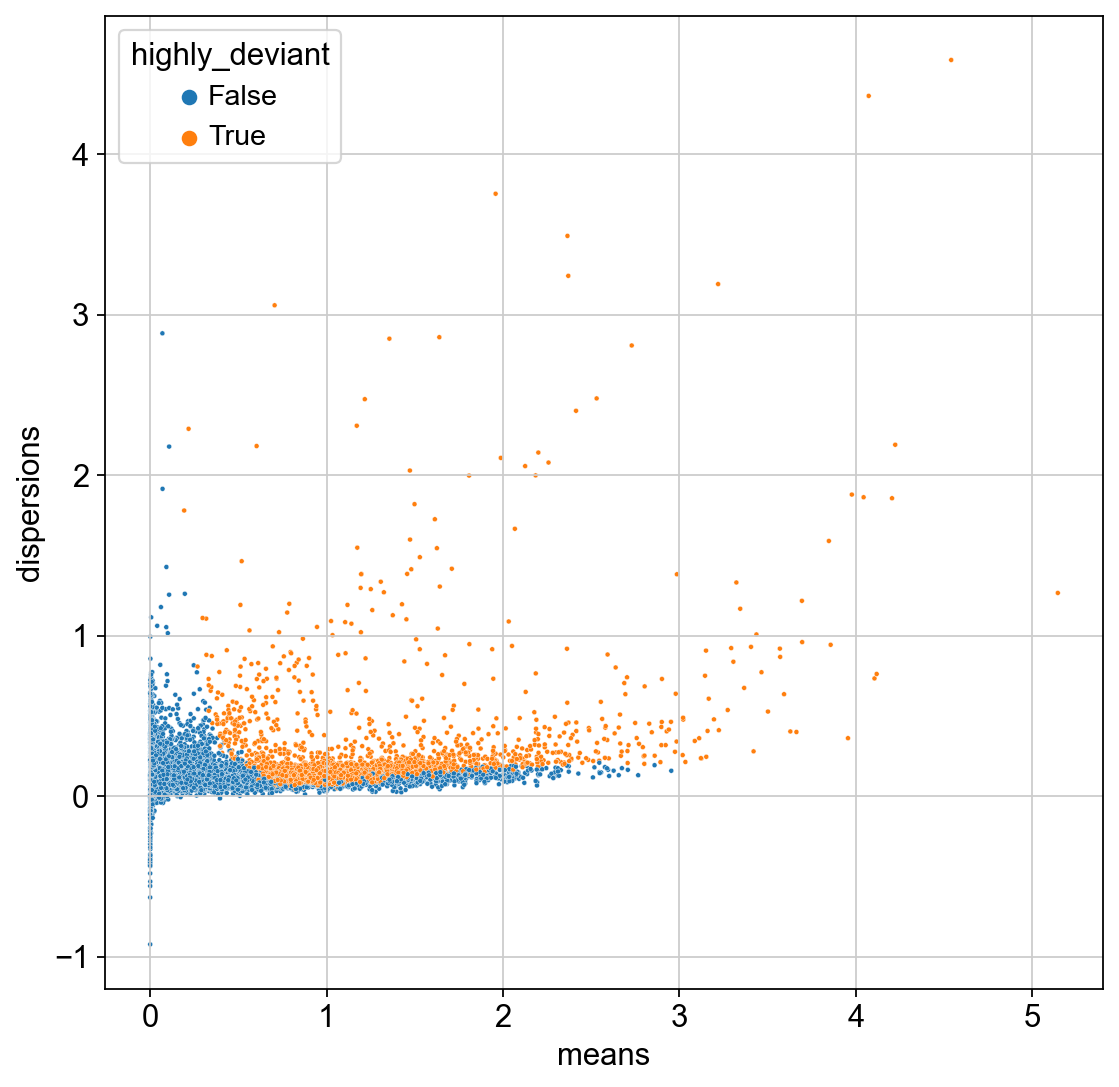

In [14]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T
adatas[i], axes2 = hvg(binomial_deviance, axes2, i, adata)

### Sample LNEN084-IARC-B

In [15]:
i = 1
sample_id = sample_ids[i]
adata = adatas[i]
print("processing sample: {}".format(sample_id))
ro.globalenv["adata"] = adata

processing sample: LNEN084-IARC-B


In [16]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


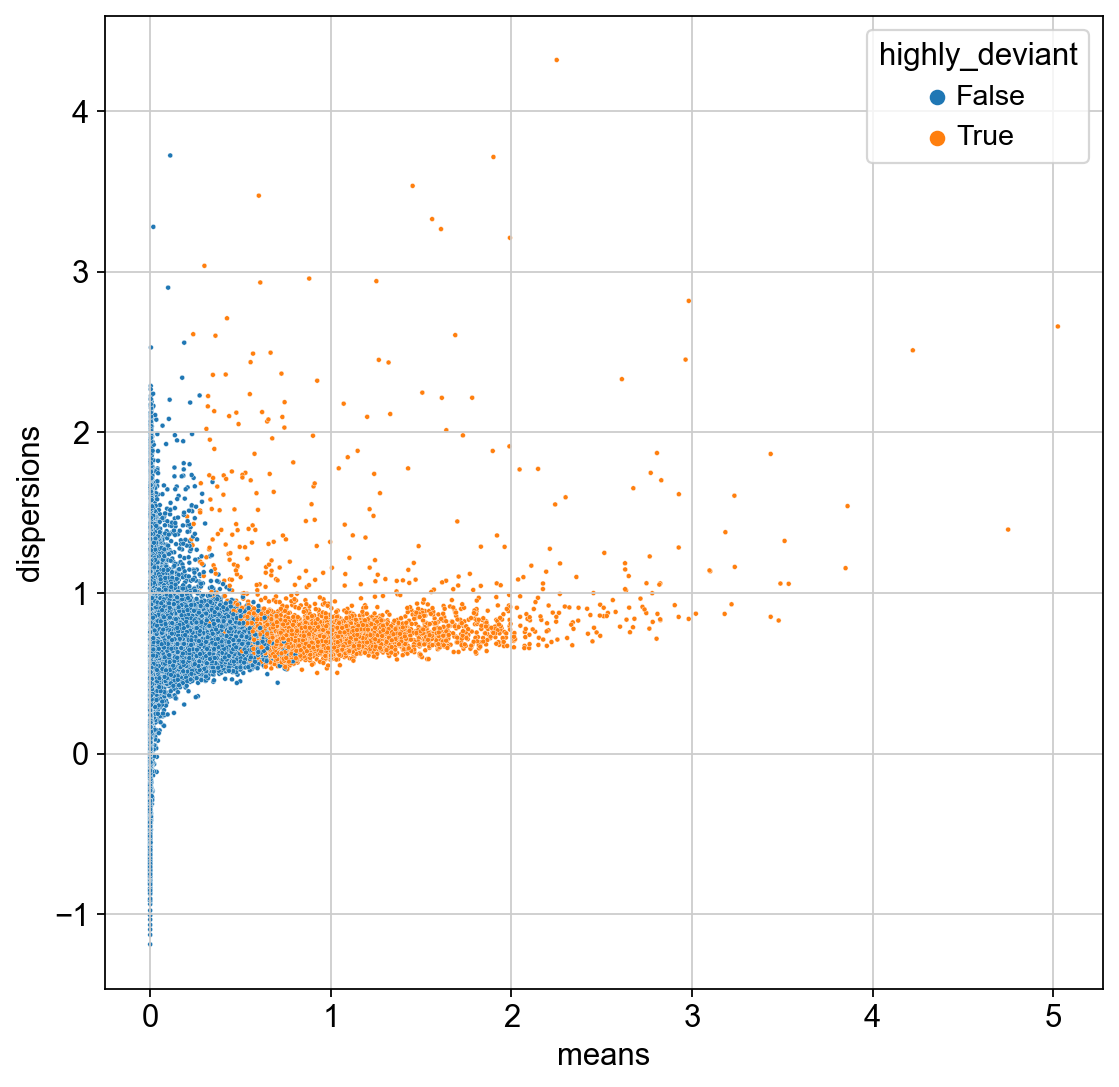

In [17]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T
adatas[i], axes2 = hvg(binomial_deviance, axes2, i, adata)

### LNEN107-IARC-C

In [18]:
i = 2
sample_id = sample_ids[i]
adata = adatas[i]
print("processing sample: {}".format(sample_id))
ro.globalenv["adata"] = adata

processing sample: LNEN107-IARC-C


In [19]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


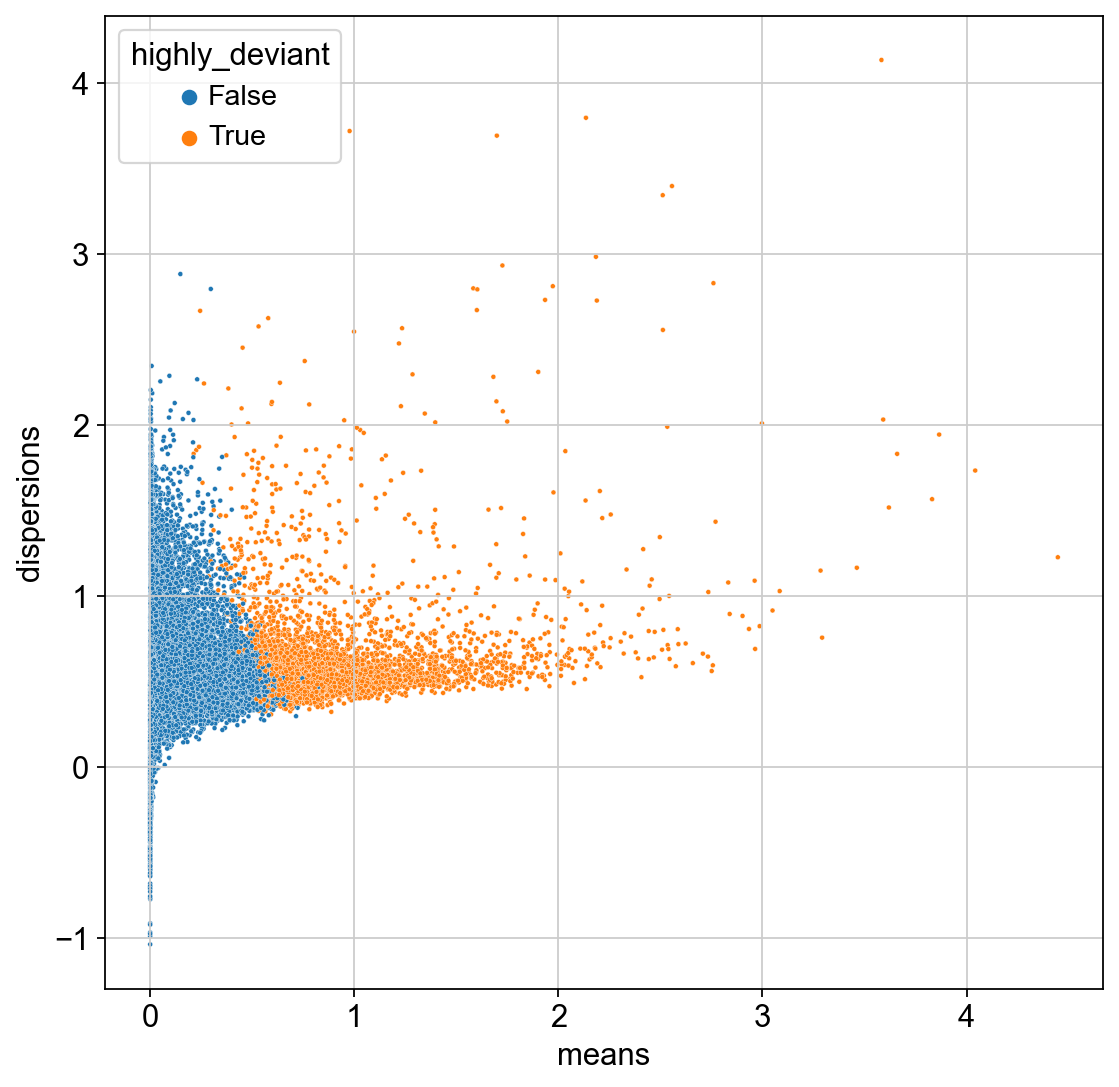

In [20]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T
adatas[i], axes2 = hvg(binomial_deviance, axes2, i, adata)

### LNEN206-IARC-D

In [21]:
i = 3
sample_id = sample_ids[i]
adata = adatas[i]
print("processing sample: {}".format(sample_id))
ro.globalenv["adata"] = adata

processing sample: LNEN206-IARC-D


In [22]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


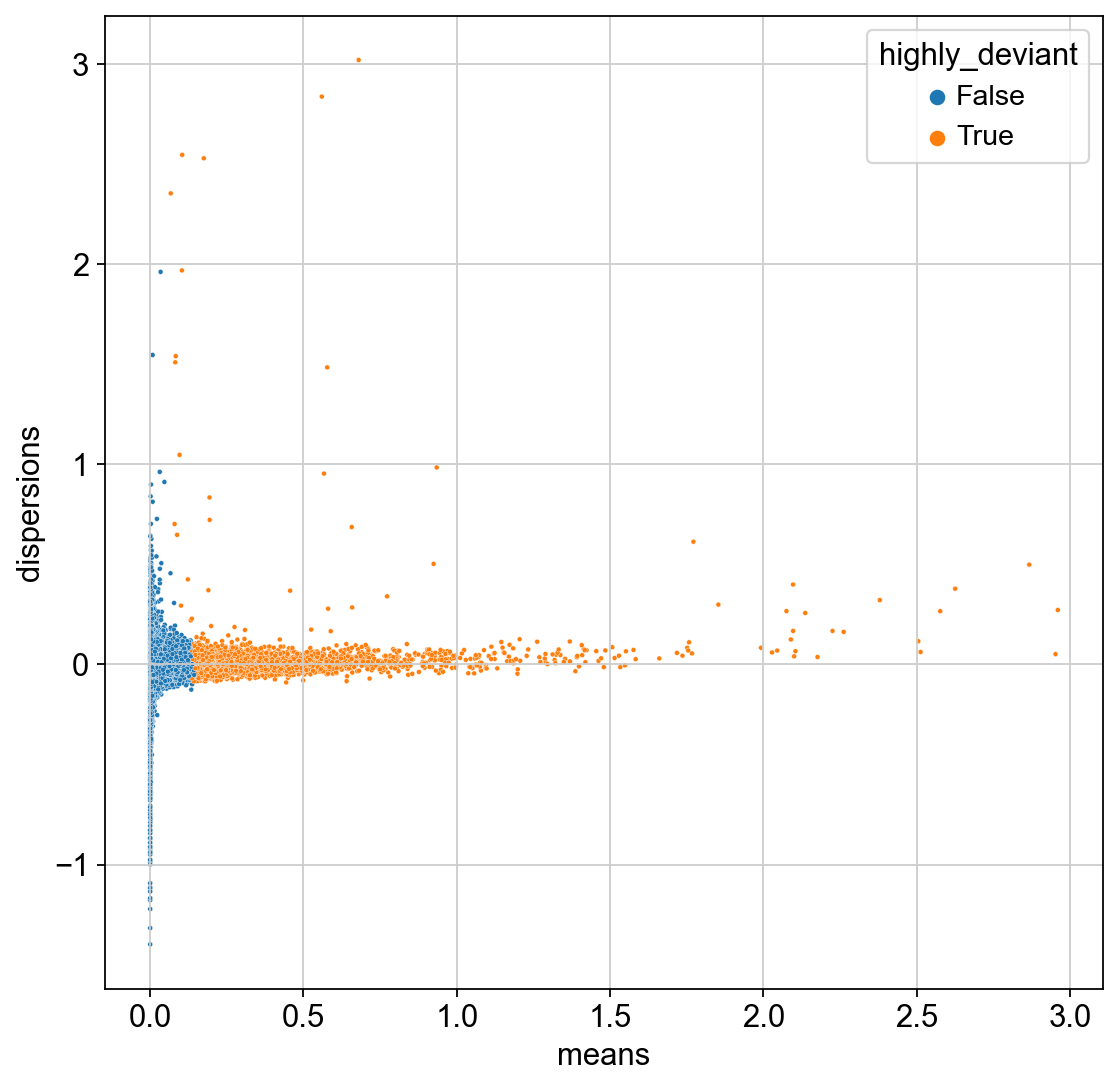

In [23]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T
adatas[i], axes2 = hvg(binomial_deviance, axes2, i, adata)

In [24]:
fig2.tight_layout()
fig2.savefig(os.path.join('ST_normalization_hvg.png'))
fig2.show()

/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_26841/1509182093.py:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()
/var/folders/l_/wbyr9x8j44q2ghtqrv1f4kkcdbjgv1/T/ipykernel_26841/1509182093.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show()


In [25]:
for i in range(len(sample_ids)):
    sample_id = sample_ids[i]
    adata = adatas[i]
    adata.write("adata_{}_scanpy_06052024.h5ad".format(sample_id))